In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import os
import gc
import glob
import apexpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_folder_to_dataframe, mjd2000_to_datetime, add_qd_gridlines
from IPython.display import clear_output


RE = 6371.2e3
RI = RE + 110e3

theta0=0.25 # for j_G matrix singularity limit

Epoch = 2025.

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
L, W, Lres, Wres = 4500e3,3500e3,100.0e3,100.0e3

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,90))

# Define meridian
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*50
meridian_lat_plot = np.arange(55, 90+0.5, 0.5)
meridian_lon_plot = np.ones(len(meridian_lat_plot))*50

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')
meridian_lat_plot, meridian_lon_plot = apex_obj.convert(meridian_lat_plot, meridian_lon_plot, 'qd', 'geo')

In [2]:
grid.shape

(32, 39)

In [3]:
stations_all = ['AMK', 'ATU', 'BBG', 'BJN', 'CY0', 'DMH', 'DNB', 'EUA', 'FAR', 'FHB', 'GDH', 'GHB', 'HLL', 'HOP', 'HOV', 'HRN', 'IGC', 'IQA', 'JAN',
 'KUV', 'LRV', 'LYR', 'NAL', 'NAN', 'NAQ', 'NRD', 'PGC', 'RES', 'SCO', 'SKT', 'STF', 'SUM', 'SVS',
 'T29', 'TAB', 'THL', 'UMQ', 'UPN']

stations = np.load('stations_supermag.npy',allow_pickle=True)
bad_stations = [s for s in stations_all if s not in stations]
# Read CSV
df = pd.read_csv("SuperMAG_stations.csv")
iaga_column = "IAGA"
lat_column = "GLAT"
lon_column = "GLON"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df[df[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()

# Read CSV
STA = pd.read_csv("dtu_stations.csv")
iaga_column = "IAGA"
lat_column = "lat_gd"
lon_column = "lon_gd"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_STA = STA[STA[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag_dtu = filtered_STA[lat_column].to_numpy()
lon_mag_dtu = filtered_STA[lon_column].to_numpy()

In [4]:
# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df_bad = df[df[iaga_column].isin(bad_stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag_bad = filtered_df_bad['GLAT'].to_numpy()
lon_mag_bad = filtered_df_bad['GLON'].to_numpy()

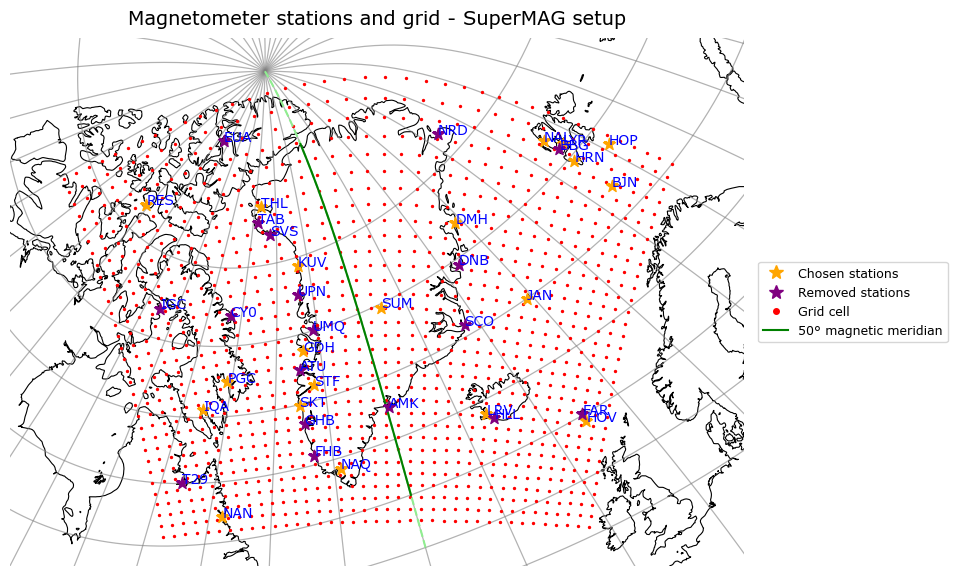

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lon = grid.lon.flatten()
lat = grid.lat.flatten()

fig = plt.figure(figsize=(10, 6))  # wider figure to accommodate legend

ax = fig.add_subplot(
    1, 1, 1,
    projection=ccrs.LambertConformal(central_longitude=-42, central_latitude=72)
)

ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=0)

ax.scatter(lon, lat, transform=ccrs.PlateCarree(), s=2, color='red', zorder=5)
ax.scatter(lon_mag, lat_mag, transform=ccrs.PlateCarree(), marker='*', s=80, color='orange', zorder=7)
ax.scatter(lon_mag_bad, lat_mag_bad, transform=ccrs.PlateCarree(), marker='*', s=80, color='purple', zorder=7)

for i, txt in enumerate(stations):
    ax.annotate(txt, (lon_mag[i], lat_mag[i]), transform=ccrs.PlateCarree(), color='blue', size=10, zorder=8)
for i, txt in enumerate(bad_stations):
    ax.annotate(txt, (lon_mag_bad[i], lat_mag_bad[i]), transform=ccrs.PlateCarree(), color='blue', size=10, zorder=8)

ax.plot(meridian_lon_plot, meridian_lat_plot, transform=ccrs.PlateCarree(), color='lightgreen', linestyle='--', zorder=6)
ax.plot(meridian_lon_geo, meridian_lat_geo, transform=ccrs.PlateCarree(), color='green', zorder=6)

ax.set_extent([-90, 10, 53, 85], crs=ccrs.PlateCarree())

# ── Remove the black frame ──────────────────────────────────────────────────
ax.spines['geo'].set_visible(False)

# ── Title ───────────────────────────────────────────────────────────────────
ax.set_title('Magnetometer stations and grid - SuperMAG setup', fontsize=14, pad=10)

# ── Legend handles (in requested order) ─────────────────────────────────────
chosen   = mlines.Line2D([], [], color='orange', marker='*', linestyle='None',
                         markersize=10, label='Chosen stations')
removed  = mlines.Line2D([], [], color='purple', marker='*', linestyle='None',
                         markersize=10, label='Removed stations')
grid_dot = mlines.Line2D([], [], color='red',    marker='o', linestyle='None',
                         markersize=4,  label='Grid cell')
meridian = mlines.Line2D([], [], color='green',  linestyle='-',
                         linewidth=1.5,           label='50° magnetic meridian')

ax.legend(
    handles=[chosen, removed, grid_dot, meridian],
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    frameon=True,
    fontsize=9,
)

# Instead of tight_layout(), manually set the axes position
# to leave room on the right for the legend
ax.set_position([0.05, 0.05, 0.80, 0.88])  # [left, bottom, width, height]

EXTENT = [-90, 10, 53, 85]   # same as ax.set_extent

add_qd_gridlines(
    ax, apex_obj,
    qlat_lines=range(50, 85, 5),   # adjust to your region
    qlon_lines=range(-180, 180, 10),
    extent=EXTENT,
    lat_color='grey',
    lon_color='grey',
    linewidth=0.9,
    alpha=0.6,
    linestyle='-',
    label_gridlines=False
)

plt.show()

**COVERAGE**

In [2]:
def compute_coverage(combined_df):
    # 1. Create the Month-Year period
    combined_df['year_month'] = combined_df['time'].dt.to_period('M')

    # 2. Calculate actual counts
    actual = combined_df.groupby(['iaga', 'year_month']).size().reset_index(name='actual_count')

    # 3. Ensure we account for missing months (reindexing)
    all_stations = combined_df['iaga'].unique()
    all_months = combined_df['year_month'].unique()
    full_index = pd.MultiIndex.from_product([all_stations, all_months], names=['iaga', 'year_month'])
    actual = actual.set_index(['iaga', 'year_month']).reindex(full_index, fill_value=0).reset_index()

    # 4. Calculate coverage percentage per specific month-year
    actual['expected_count'] = actual['year_month'].apply(lambda p: p.days_in_month * 24 * 60)
    actual['coverage_pct'] = (actual['actual_count'] / actual['expected_count'] * 100).round(2)

    # 5. Extract the month number from the period
    actual['month_num'] = actual['year_month'].dt.month

    # 6. AVERAGE the coverage across years for each station/month
    # This collapses multiple years into a single 1-12 month set
    monthly_avg = actual.groupby(['iaga', 'month_num'])['coverage_pct'].mean().reset_index()

    # 7. Pivot to get the 12-column format
    coverage = monthly_avg.pivot(index='iaga', columns='month_num', values='coverage_pct')
    
    # Optional: ensure column names are clean
    coverage.columns.name = 'month'
    
    return coverage

In [3]:
def compute_concurrent_coverage(combined_df):
    # Determine the "all stations" threshold
    total_stations = combined_df['iaga'].nunique()

    # 1. Count unique stations per minute
    per_minute = combined_df.groupby('time')['iaga'].nunique().reset_index(name='station_count')
    
    # 2. Identify and extract the specific timestamps with full concurrency
    per_minute['is_concurrent'] = per_minute['station_count'] == total_stations
    concurrent_times = per_minute.loc[per_minute['is_concurrent'], 'time']

    # 3. Calculate coverage per specific month-year
    per_minute['year_month'] = per_minute['time'].dt.to_period('M')
    
    actual_concurrent_minutes = per_minute.groupby('year_month')['is_concurrent'].sum()
    expected_minutes = per_minute.groupby('year_month')['year_month'].first().apply(
        lambda p: p.days_in_month * 24 * 60
    )
    
    monthly_coverage = (actual_concurrent_minutes / expected_minutes * 100)

    # 4. Collapse multiple years into a 1-12 month average
    df_coverage = monthly_coverage.reset_index(name='coverage_pct')
    df_coverage['month'] = df_coverage['year_month'].dt.month
    
    final_avg_coverage = df_coverage.groupby('month')['coverage_pct'].mean().round(2)
    final_avg_coverage.name = 'concurrent_coverage_pct'
    
    # Return both the monthly stats and the list of timestamps
    return final_avg_coverage, concurrent_times

In [5]:
def read_fn(years, baseline):
    all_dfs = []  # Use a clear name for the list of DataFrames

    for year in years:
        if baseline=='none':
            folder_path = f'supermag_downloads/no_baseline/{year}'
        elif baseline=='yearly':
            folder_path = f'supermag_downloads/yearly_baseline/{year}'
        files = glob.glob(os.path.join(folder_path, "*.csv"))

        for file in files:
            # Read and select columns immediately
            df = pd.read_csv(file)[['time', 'iaga', 'dbn_geo']]
            all_dfs.append(df)

    # Combine EVERYTHING at once after all loops finish
    if not all_dfs:
        return pd.DataFrame() # Handle case where no files are found

    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Sorting and formatting
    combined_df['time'] = pd.to_datetime(combined_df['time'])
    combined_df = combined_df.sort_values(
        by=["time", 'iaga'],
        ascending=[True, True]
    ).reset_index(drop=True)

    ## REMOVE NANS
    combined_df = combined_df.dropna(subset=['dbn_geo'])
    
    return combined_df

In [6]:
combined_df = read_fn([2023,2024,2025], baseline='none')

In [13]:
bad_stations = coverage_mean.index.values[(coverage_mean.mean(axis=1) < 50)] # inspection of plots
bad_stations

<StringArray>
['ATU', 'CY0', 'FHB', 'IGC', 'SVS', 'T29', 'TAB', 'UMQ', 'UPN']
Length: 9, dtype: str

In [9]:
combined_df_filtered = combined_df[~combined_df['iaga'].isin(bad_stations)]
combined_df_bad = combined_df[combined_df['iaga'].isin(bad_stations)]

In [14]:
coverage_mean = compute_coverage(combined_df_filtered)
concurrent_mean, concurrent_times = compute_concurrent_coverage(combined_df_filtered)

In [44]:
np.save('concurrent_times_supermag',concurrent_times)

In [17]:
coverage_mean_bad = compute_coverage(combined_df_bad)
concurrent_mean_bad, _ = compute_concurrent_coverage(combined_df_bad)

In [43]:
concurrent_times.size/60/24

183.46666666666667

In [ ]:
stations_all = coverage_mean.index.values
np.save('stations_supermag.npy',stations_all)

In [21]:
coverage_mean.shape[0]

20

In [22]:
coverage_mean

month,1,2,3,4,5,6,7,8,9,10,11,12
iaga,,,,,,,,,,,,
BJN,97.836667,98.810000,94.190000,99.953333,99.923333,99.980000,98.980000,70.333333,71.666667,78.486667,99.900,99.895
DMH,84.166667,96.143333,99.053333,83.003333,32.840000,77.413333,47.983333,0.000000,11.910000,59.060000,94.045,95.400
GDH,99.983333,98.473333,99.963333,99.993333,99.973333,99.916667,88.723333,99.996667,98.456667,78.310000,96.300,99.290
HOP,97.833333,98.633333,89.653333,100.000000,99.863333,99.986667,99.963333,99.563333,99.826667,78.380000,99.960,99.870
HOV,98.910000,98.850000,87.956667,99.946667,99.430000,100.000000,99.996667,100.000000,99.940000,78.493333,89.515,100.000
HRN,96.426667,94.070000,89.850000,95.740000,84.056667,89.660000,100.000000,97.773333,95.890000,75.653333,97.165,99.960
IQA,98.966667,97.926667,98.010000,100.000000,87.553333,100.000000,99.766667,98.506667,98.556667,78.496667,99.085,100.000
JAN,97.790000,98.846667,99.996667,100.000000,99.233333,99.990000,100.000000,99.640000,99.596667,78.480000,99.950,100.000
KUV,96.643333,70.476667,29.550000,76.770000,95.636667,97.323333,69.210000,64.520000,66.636667,66.010000,97.425,100.000


In [23]:
concurrent_mean

month
1     52.60
2     27.81
3     10.82
4     22.70
5     26.85
6     12.31
7      0.00
8      0.00
9      0.00
10     0.00
11    28.08
12    44.84
Name: concurrent_coverage_pct, dtype: float64

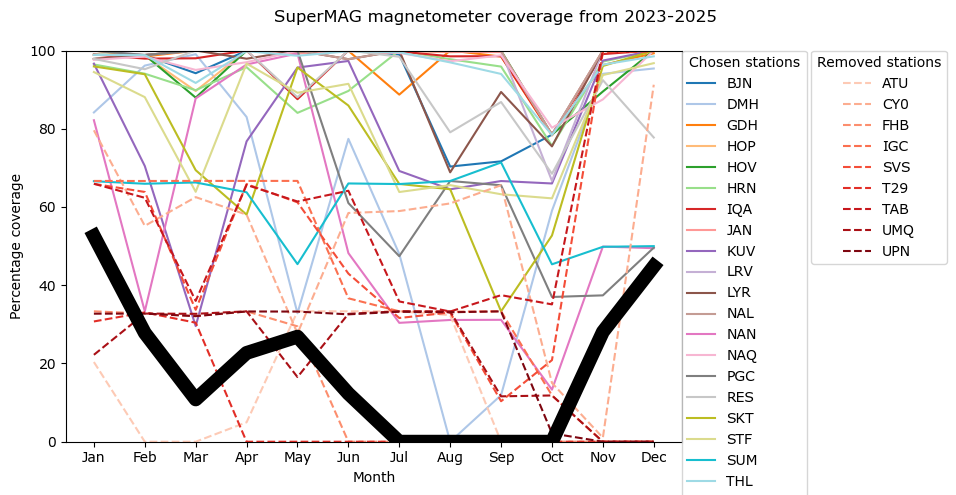

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

# --- Group 1: use tab20 or another large colormap ---
g1_stations = coverage_mean.index.values
g1_colors = cm.tab20(np.linspace(0, 1, len(g1_stations)))

group1_lines = []
for sta, color in zip(g1_stations, g1_colors):
    line, = ax.plot(coverage_mean.loc[sta].values, label=sta, color=color)
    group1_lines.append(line)

# --- Group 2: use a warm/muted colormap to signal exclusion ---
g2_stations = coverage_mean_bad.index.values
g2_colors = cm.Reds(np.linspace(0.2, 0.95, len(g2_stations)))

group2_lines = []
for sta, color in zip(g2_stations, g2_colors):
    line, = ax.plot(coverage_mean_bad.loc[sta].values, label=sta, color=color, linestyle='--')
    group2_lines.append(line)

# --- Concurrent mean ---
concurrent_line, = ax.plot(concurrent_mean.values, color='black', lw=10, label='concurrent')
group1_lines.append(concurrent_line)

ax.set_ylabel('Percentage coverage')
ax.set_xlabel('Month')
ax.set_xticks(range(0, 12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylim(0, 100)

legend1 = ax.legend(
    handles=group1_lines,
    labels=[l.get_label() for l in group1_lines],
    title='Chosen stations',
    loc='upper left',
    bbox_to_anchor=(1, 1),
    borderaxespad=0
)

legend2 = ax.legend(
    handles=group2_lines,
    labels=[l.get_label() for l in group2_lines],
    title='Removed stations',
    loc='upper left',
    bbox_to_anchor=(1.21, 1),
    borderaxespad=0
)

ax.add_artist(legend1)
fig.suptitle('SuperMAG magnetometer coverage from 2023-2025')
fig.tight_layout()
plt.show()